In [1]:
import numpy as np
import scanpy as sc
import functions as fn
import matplotlib.pyplot as plt


In [9]:
datapath = "C:\\Users\\rdbra\\Documents\\honoursProject\\code_base\\Hon_proj_RDB\\GRN_work\\results\\sct_top5k_1000_7_vqvae2\\vqvae2_recon.npz"
data = np.load(datapath)
print(data.files)


['reconstructed_matrix']


In [ ]:
recon = data['reconstructed_matrix']

KeyError: 'recon is not a file in the archive'

In [6]:
num_bins = 7  # Based on scBert bin countz

In [7]:
'''
Perform some basic single cell analysis to visualise the data prior to binning 
The following plots will be generated, heatmap of gene expression within each cell.
- Gene expression heatmap
- Frequency plot of gene expression values
- Histogram of gene expression values
- Histogram of gene expression quantiles
'''
# 1. Gene expression heatmap
print("Generating gene expression heatmap...")
# Create an AnnData object if not already working with one
if 'adata' not in locals() or not isinstance(adata, sc.AnnData):
    adata = sc.AnnData(X=data)
# assign non-zero data
nonzero_data = adata.X[adata.X > 0]
# Select top genes by variance for the heatmap (to avoid overcrowding)

# n_top_genes = 50
# top_genes_idx = np.argsort(gene_variances)[-n_top_genes:]
# plt.figure(figsize=(12, 10))
# sc.pl.heatmap(adata, var_names=top_genes_idx, n_obs=100, show=False)
# plt.title("Gene Expression Heatmap (Top 50 genes by variance)")
# plt.tight_layout()
# plt.show()


Generating gene expression heatmap...


ValueError: X needs to be of one of <class 'numpy.ndarray'>, <class 'numpy.ma.MaskedArray'>, <class 'scipy.sparse._csr.csr_matrix'>, <class 'scipy.sparse._csc.csc_matrix'>, <class 'scipy.sparse._csr.csr_array'>, <class 'scipy.sparse._csc.csc_array'>, <class 'h5py._hl.dataset.Dataset'>, <class 'zarr.core.array.Array'>, <class 'anndata.compat.ZappyArray'>, <class 'anndata.abc.CSRDataset'>, <class 'anndata.abc.CSCDataset'>, <class 'anndata.compat.DaskArray'>, <class 'anndata.compat.CupyArray'>, <class 'anndata.compat.CupySparseMatrix'>, <class 'anndata.compat.AwkArray'>, or <class 'anndata.compat.XDataArray'>, not <class 'numpy.lib.npyio.NpzFile'>.

Generating visualization of non-zero gene expression range...


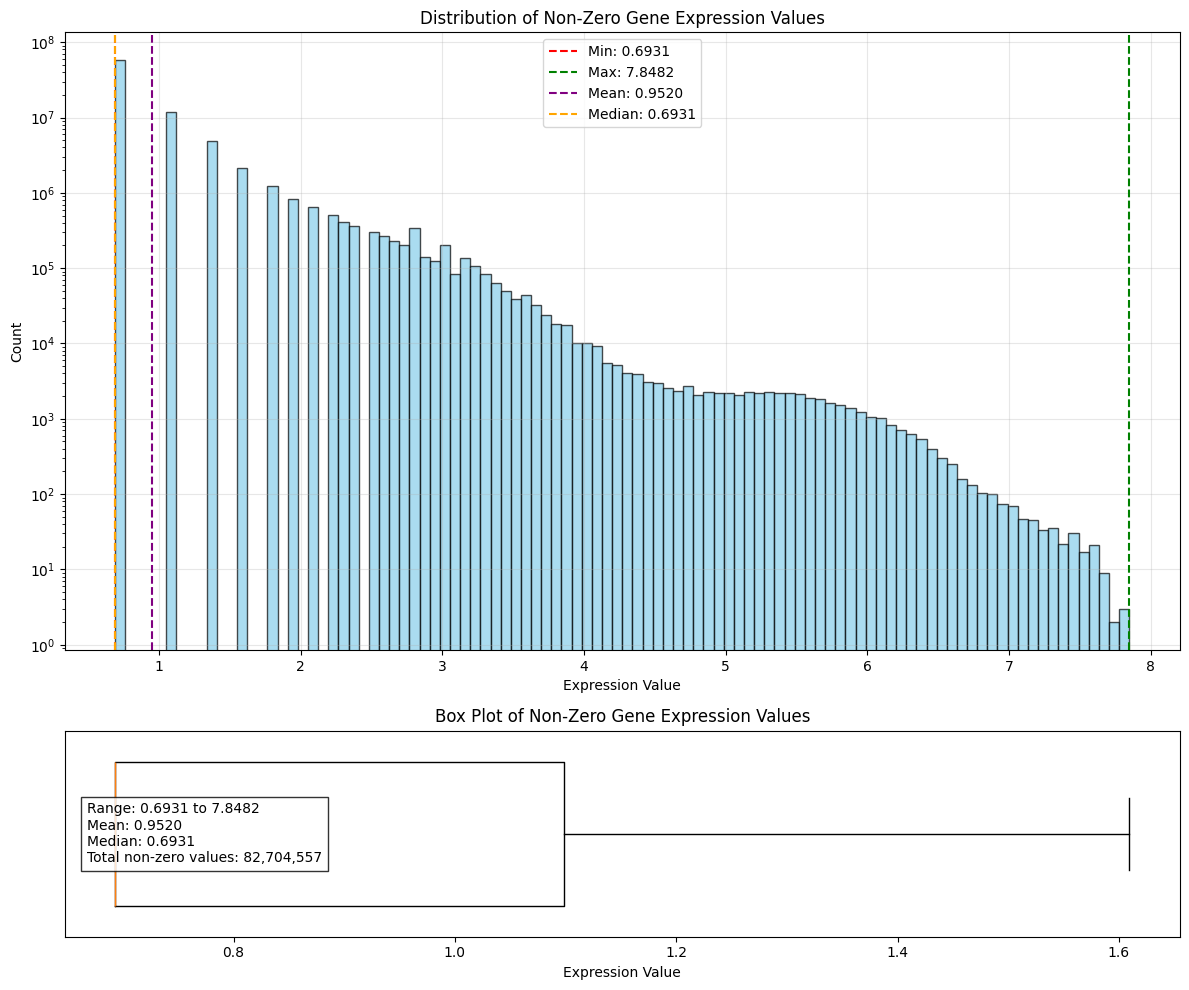

In [ ]:

# 2. Plot the range of non-zero gene expression values
print("Generating visualization of non-zero gene expression range...")

# Calculate statistics for non-zero values
min_val = np.min(nonzero_data)
max_val = np.max(nonzero_data)
mean_val = np.mean(nonzero_data)
median_val = np.median(nonzero_data)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot histogram in the first subplot
counts, bins, patches = ax1.hist(nonzero_data, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title("Distribution of Non-Zero Gene Expression Values")
ax1.set_xlabel("Expression Value")
ax1.set_ylabel("Count")
ax1.set_yscale('log')  # Log scale for better visibility
ax1.grid(alpha=0.3)

# Add vertical lines for statistics
ax1.axvline(min_val, color='red', linestyle='--', label=f'Min: {min_val:.4f}')
ax1.axvline(max_val, color='green', linestyle='--', label=f'Max: {max_val:.4f}')
ax1.axvline(mean_val, color='purple', linestyle='--', label=f'Mean: {mean_val:.4f}')
ax1.axvline(median_val, color='orange', linestyle='--', label=f'Median: {median_val:.4f}')
ax1.legend()

# Create a box plot in the second subplot
ax2.boxplot(nonzero_data, vert=False, showfliers=False, widths=0.7)
ax2.set_title("Box Plot of Non-Zero Gene Expression Values")
ax2.set_xlabel("Expression Value")
ax2.set_yticks([])  # Hide y-ticks for cleaner visualization

# Add text annotations with stats
stats_text = (f"Range: {min_val:.4f} to {max_val:.4f}\n"
              f"Mean: {mean_val:.4f}\n"
              f"Median: {median_val:.4f}\n"
              f"Total non-zero values: {len(nonzero_data):,}")
ax2.text(0.02, 0.5, stats_text, transform=ax2.transAxes, 
         bbox=dict(facecolor='white', alpha=0.8), verticalalignment='center')
plt.tight_layout()
plt.show()



In [ ]:

# 3. Histogram of gene expression values
print("Generating histogram of gene expression values...")
plt.figure(figsize=(10, 6))
# Random sample of expression values to avoid memory issues
sample_size = min(10000000, data.size)
sample_indices = np.random.choice(data.size, size=sample_size, replace=False)
sample_data = data.flatten()[sample_indices]
plt.hist(sample_data, bins=100, color='skyblue', edgecolor='black')
plt.title("Histogram of Gene Expression Values")
plt.xlabel("Expression Value")
plt.ylabel("Count")
plt.yscale('log')  # Log scale for better visibility of distribution
plt.grid(alpha=0.3)
plt.show()


Generating histogram of gene expression quantiles...
8 quantiles calculated.
Quantiles: [0.69314718 0.69314718 0.69314718 0.69314718 0.69314718 1.09861229
 1.38629436 7.84815309]
Counts per bin: [       0        0        0        0 57289785 11762442 13652330]


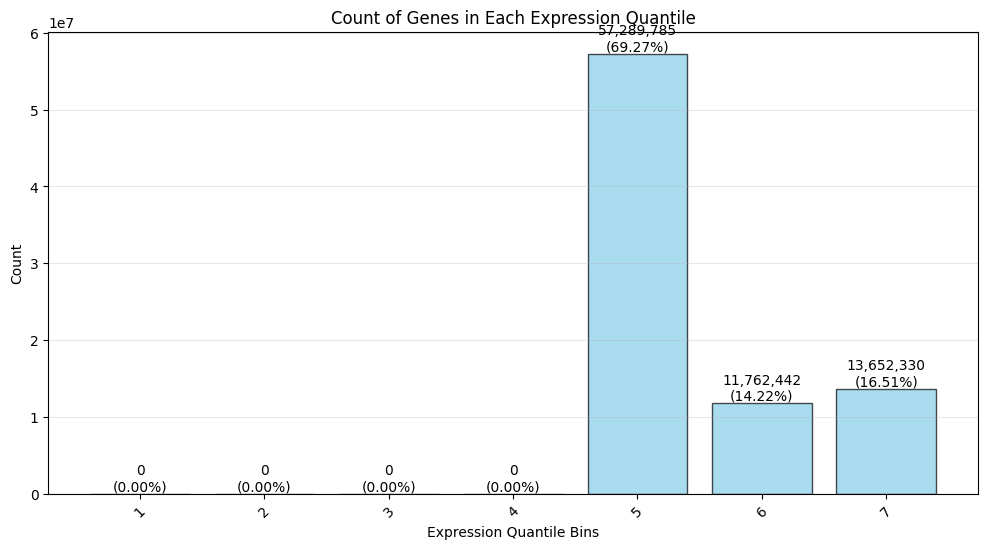

In [ ]:

# 4. Histogram of gene expression quantiles
print("Generating histogram of gene expression quantiles...")# Remove NaN values
# Calculate quantiles
percentiles = np.linspace(0, 100, num_bins + 1)
quantiles = np.percentile(nonzero_data, percentiles)
print(len(quantiles), "quantiles calculated.")
print("Quantiles:", quantiles) 
#Calculate the count of genes within each quantile
# Calculate counts of values in each quantile bin
counts, _ = np.histogram(nonzero_data, bins=quantiles)

print("Counts per bin:", counts)
# Plot the histogram
plt.figure(figsize=(12, 6))
bin_labels = range(1,num_bins+1)
bars = plt.bar(range(len(counts)), counts, alpha=0.7, color='skyblue', edgecolor='black')
plt.title("Count of Genes in Each Expression Quantile")
plt.xlabel("Expression Quantile Bins")
plt.ylabel("Count")
plt.xticks(range(len(counts)), bin_labels, rotation=45)
plt.grid(axis='y', alpha=0.3)
#calculate percentages
percentages = 100 * counts / counts.sum()
# Add count and percentage labels on each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{counts[i]:,}\n({percentages[i]:.2f}%)',
             ha='center', va='bottom', rotation=0)
plt.show()


In [ ]:
# Perform binning using the term_freq_bin method
binned_data = fn.term_freq_bin(data, num_bins)

# Check the shape of the binned data
print("Binned data shape:", binned_data.shape)

# Plot the frequency of each binned value
plt.figure(figsize=(12, 6))
flat_binned = binned_data.flatten()
bin_values, bin_counts = np.unique(flat_binned, return_counts=True)

# Create a colormap for better visual distinction
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(bin_values)))

# Plot the bars with different colors
bars = plt.bar(bin_values, bin_counts, alpha=0.8, color=colors, edgecolor='black', width=0.7)

# Add count and percentage labels on each bar
total_count = len(flat_binned)
for bar, value, count in zip(bars, bin_values, bin_counts):
    percentage = (count / total_count) * 100
    plt.text(bar.get_x() + bar.get_width()/2., count + (max(bin_counts) * 0.01), 
             f'{count:,}\n({percentage:.2f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title(f"Frequency Distribution of Binned Values (using {num_bins} bins)")
plt.xlabel("Bin Value (Expression Level)")
plt.ylabel("Frequency (Count)")
plt.xticks(bin_values)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

(51099, 16647) [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
The unique bin edges are: [0.         7.84815309]


KeyboardInterrupt: 

In [ ]:
bins = [0,1,2,3,4]
test_data = np.random.randint(0, 20, size=10)
print(test_data, type(test_data))
binned_data = fn.term_freq_bin(test_data, num_bins)
print(binned_data)

[ 8 14  2 17 19  9 17  4  5 17] <class 'numpy.ndarray'>
Data will be binned into 7 bins.
(10,) [ 8 14  2 17 19  9 17  4  5 17]
The unique bin edges are: [ 2.          4.28571429  6.71428571  8.85714286 14.42857143 17.
 19.        ]
[3 4 1 6 7 4 6 1 2 6]
